In [3]:
import pandas as pd

## Load agent name

In [4]:
# How to read_csv from google sheet https://medium.com/@Bwhiz/step-by-step-guide-importing-google-sheets-data-into-pandas-ae2df899257f
sheet_name = 'Agent' # replace with your own sheet name
sheet_id = '1QXAKFfXR8oBMXL_mVJx3SkqEpN0qIRG5davdcwCq1-0' # replace with your sheet's ID
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"

agent_list = pd.read_csv(url)
agent_list.head()

,prefix_name,agent name,Unnamed: 2
0,property,Nut Ananganjanagit,NaN
1,asset,eakapong_r,NaN
2,condo,Pluto_Landmarks,NaN
3,estate,MaxTierRealty,NaN
4,prop,suwit,NaN


In [5]:
agent_name_list = agent_list['agent name'].dropna().str.lower().tolist()
prefix_name = agent_list['prefix_name'].dropna().str.lower().tolist()

In [6]:
print(len(agent_name_list))
print(len(prefix_name))

128
29


## Load facebook_posts.csv

In [43]:
fb_posts = pd.read_csv("./csv_files/facebook/facebook_posts.csv")
fb_posts = fb_posts.drop('Unnamed: 0', axis=1)
fb_posts.head()

,author,content,post_link,post_id
0,Pongpun Jukkaew,ลุมพินี พหล 32 ห้องใหม่ จองด่วนครับ!!!… See ...,https://www.facebook.com/groups/13961451675220...,«R2kbddaulqlaleillkqismipapd5aqH1» «R2kbddaulq...
1,Jenroob N. Siritharathikun,NaN,https://www.facebook.com/groups/13961451675220...,«r4l» «r4m» «r4n» «r4p» «r4o»
2,กัญฑมาศ หิมะเซ็น,NaN,https://www.facebook.com/groups/13961451675220...,«r6b» «r6c» «r6d» «r6f» «r6e»
3,อรรถพร พรหมเจริญ,ให้เช่าคอนโด \nThe Selected Kaset-Ngamwongwan\...,https://www.facebook.com/groups/13961451675220...,«r7b» «r7c» «r7d» «r7f» «r7e»
4,Arnut Kritsanakan,ปล่อยเช่า Chewathai เกษตร-นวมินทร์\nขนาด 25 ต...,https://www.facebook.com/groups/13961451675220...,«r81» «r82» «r83» «r85» «r84»


In [44]:
fb_posts.isna().sum()

author       0
content      6
post_link    4
post_id      0
dtype: int64

In [45]:
fb_posts = fb_posts.dropna(subset=['post_link'])

In [46]:
fb_posts.isna().sum()

author       0
content      2
post_link    0
post_id      0
dtype: int64

In [47]:
len(fb_posts)

26

## Check length and split to 2 DataFrames

In [48]:
import matplotlib.pyplot as plt

In [63]:
room_seeker_df = fb_posts[fb_posts['content'].str.len() <= 150]
room_renter_df = fb_posts[fb_posts['content'].str.len() > 150]
null_df = fb_posts[fb_posts['content'].isnull() == True]

# Concat null_df with room_seeker_df
room_seeker_df = pd.concat([room_seeker_df, null_df])

[Text(0, 0, '5'), Text(0, 0, '21')]

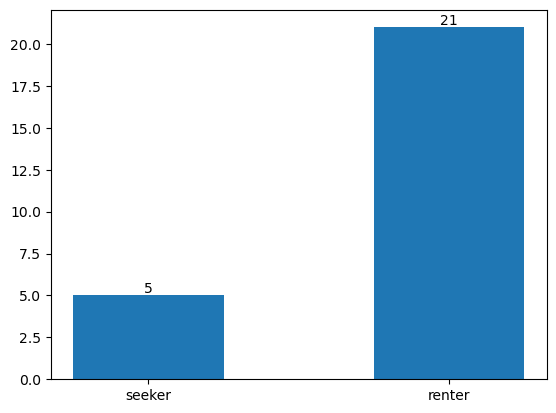

In [64]:
number_of_seeker = len(room_seeker_df)
number_of_renter = len(room_renter_df)

number_of_posts = plt.bar(x=["seeker", "renter"], height=[number_of_seeker, number_of_renter], width=0.5)
plt.bar_label(number_of_posts, labels=[number_of_seeker, number_of_renter])